#Problem Statement

The INN Hotels Group, is facing a high rate of booking cancellations. These cancellations, especially last-minute ones, lead to significant revenue loss, increased operational costs, and reduced profit margins. The goal is to analyze historical booking data to uncover key patterns that influence booking cancellations. The insights from this exploratory analysis will support the development of a machine learning model to predict and potentially mitigate cancellations.

***Data Dictionary:***

•	Booking_ID: the unique identifier of each booking

•	no_of_adults: Number of adults

•	no_of_children: Number of Children

•	no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

•	no_of_week_nights: Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel

•	type_of_meal_plan: Type of meal plan booked by the customer:

    •	Not Selected – No meal plan selected
    •	Meal Plan 1 – Breakfast
    •	Meal Plan 2 – Half board (breakfast and one other meal)
    •	Meal Plan 3 – Full board (breakfast, lunch, and dinner)

•	required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)

•	room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group

•	lead_time: Number of days between the date of booking and the arrival date

•	arrival_year: Year of arrival date

•	arrival_month: Month of arrival date

•	arrival_date: Date of the month

•	market_segment_type: Market segment designation.

•	repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)

•	no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking

•	no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking

•	avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)

•	no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)

•	booking_status: Flag indicating if the booking was canceled or not.


Let's mount the drive and read the given csv data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/PGP/INNHotelsGroup.csv')
display(df.head())

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [3]:
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In [4]:
df.shape

(36275, 19)

In [5]:
df.dtypes

,0
Booking_ID,object
no_of_adults,int64
no_of_children,int64
no_of_weekend_nights,int64
no_of_week_nights,int64
type_of_meal_plan,object
required_car_parking_space,int64
room_type_reserved,object
lead_time,int64
arrival_year,int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [7]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


In [9]:
df.describe(include='object')

,Booking_ID,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
count,36275,36275,36275,36275,36275
unique,36275,4,7,5,2
top,INN36275,Meal Plan 1,Room_Type 1,Online,Not_Canceled
freq,1,27835,28130,23214,24390


In [10]:
df.describe(include=["object"]).T

,count,unique,top,freq
Booking_ID,36275,36275,INN36275,1
type_of_meal_plan,36275,4,Meal Plan 1,27835
room_type_reserved,36275,7,Room_Type 1,28130
market_segment_type,36275,5,Online,23214
booking_status,36275,2,Not_Canceled,24390


* Wecan drop Booking_ID as it doesn't any significant value

* type_of_meal_plan: Most of the customer orders Meal Plan 1 which is only breakfast

* room_type_reserved: Most of the customers booked Room_type1

* market_segment_type: Most of the customers books the room in online mode

* booking_status: Most of the customers not cancels the request once they booked

**Check for duplicate value**

In [11]:
df.duplicated().sum()

np.int64(0)

**Check for missing values**

In [12]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


No missing values found

**Feature Engineering**

In [13]:
# Dropping Booking_ID
df.drop(["Booking_ID"], axis=1, inplace=True)

#EDA

**Univariate Analysis**

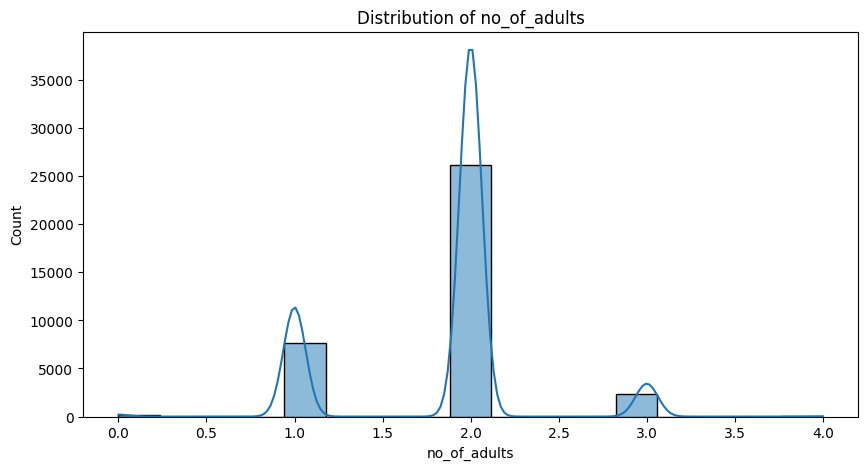

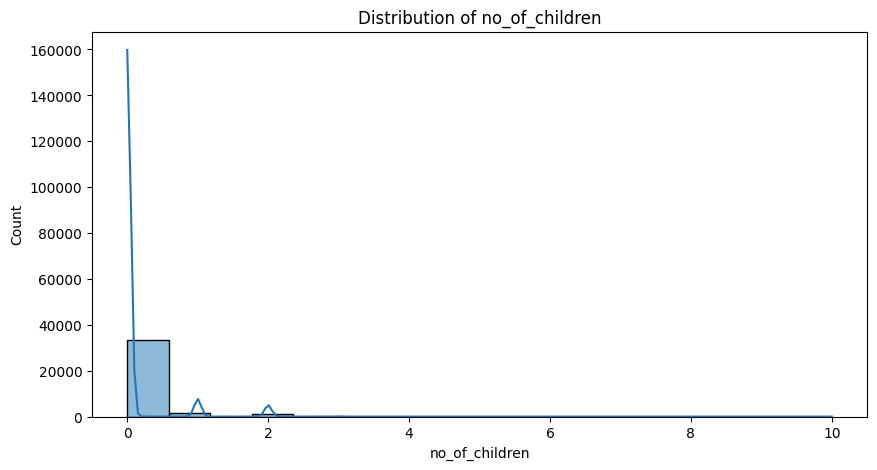

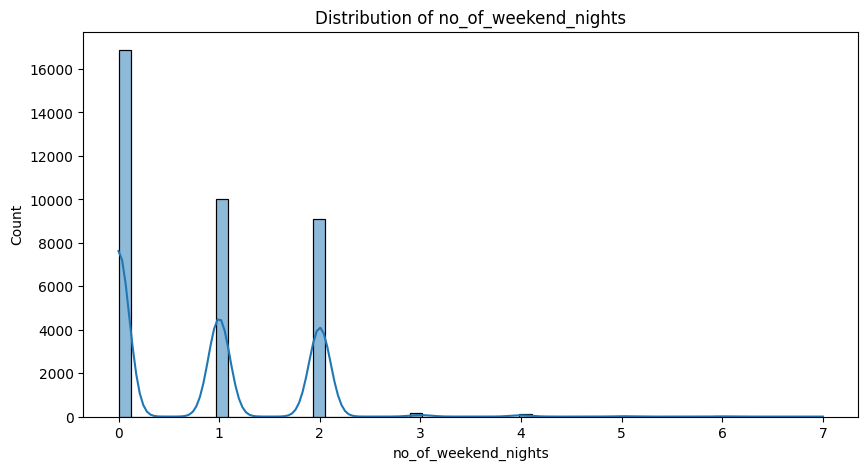

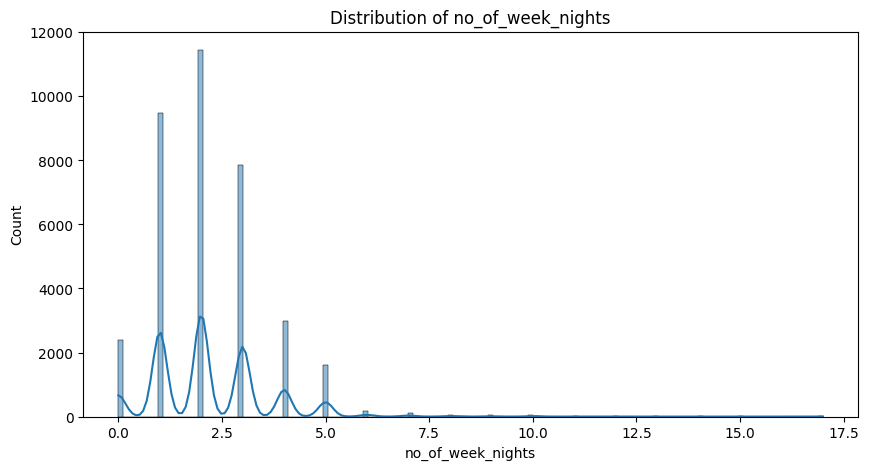

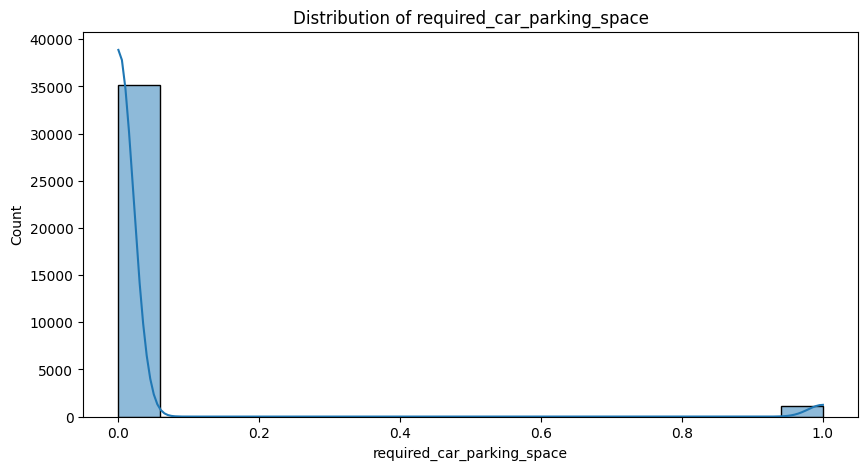

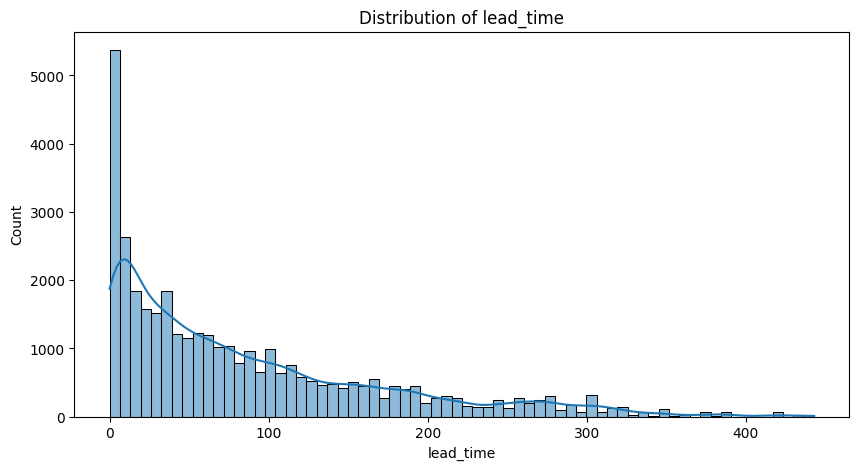

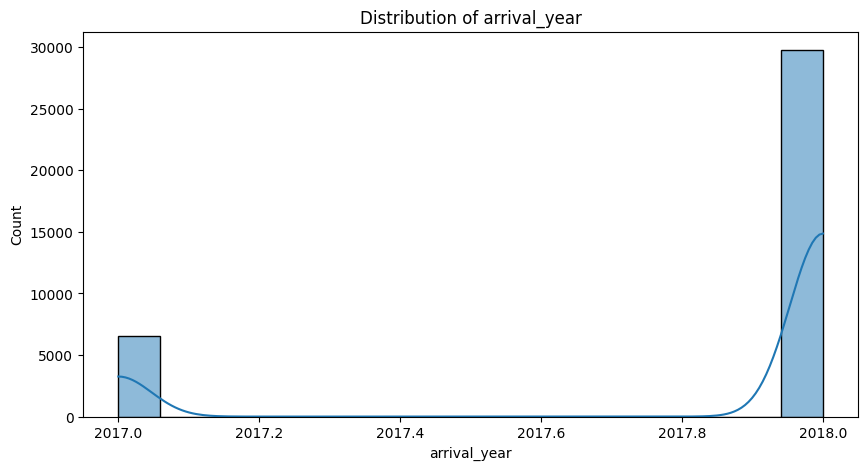

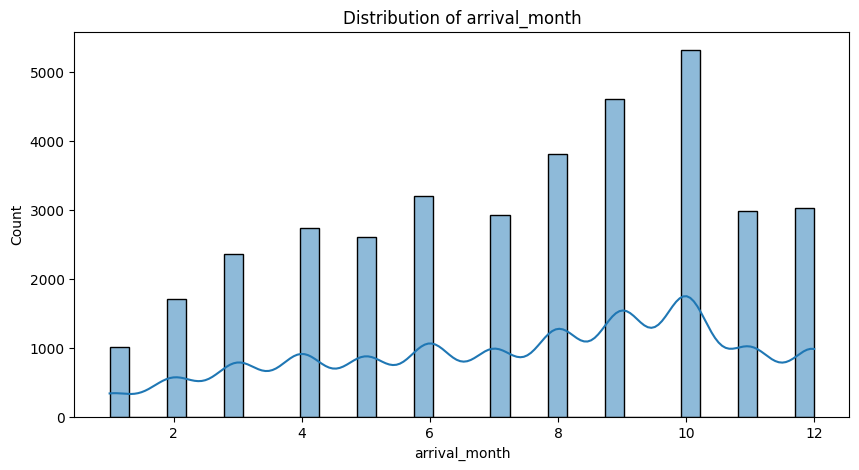

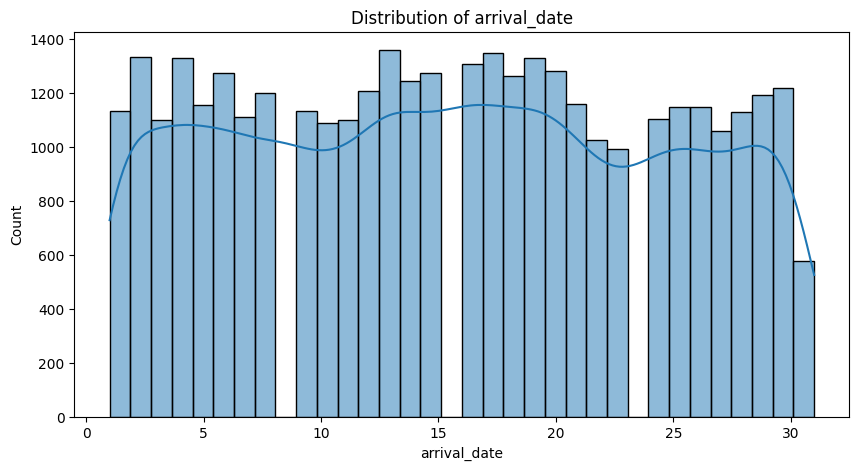

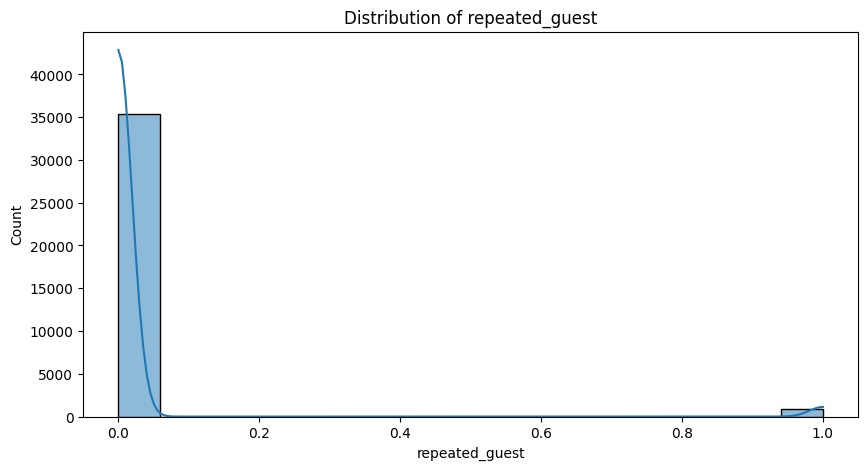

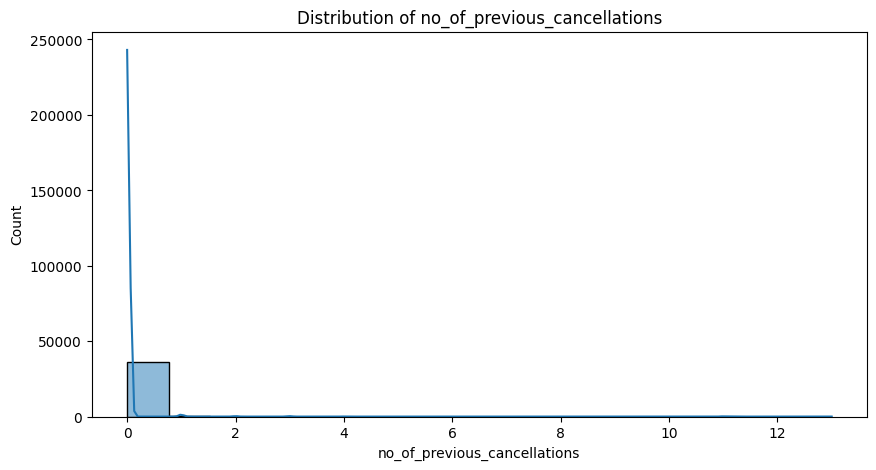

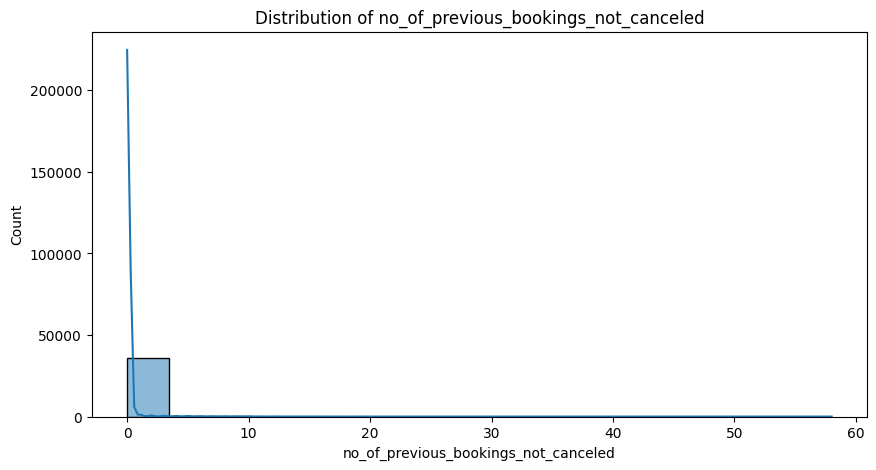

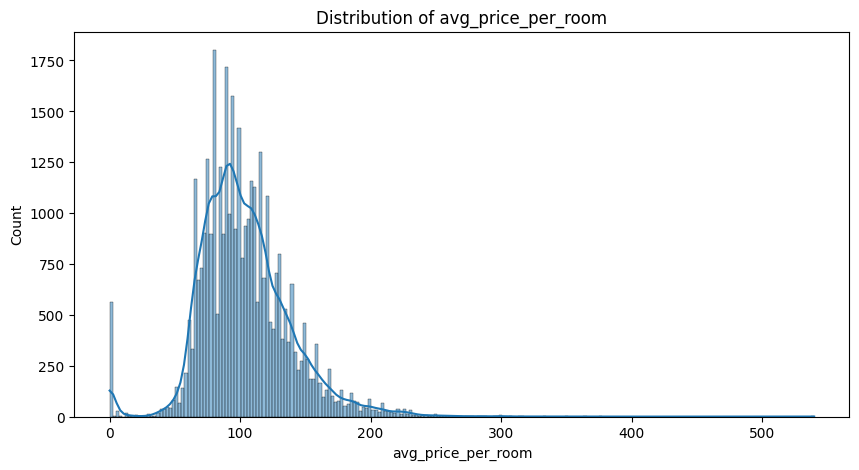

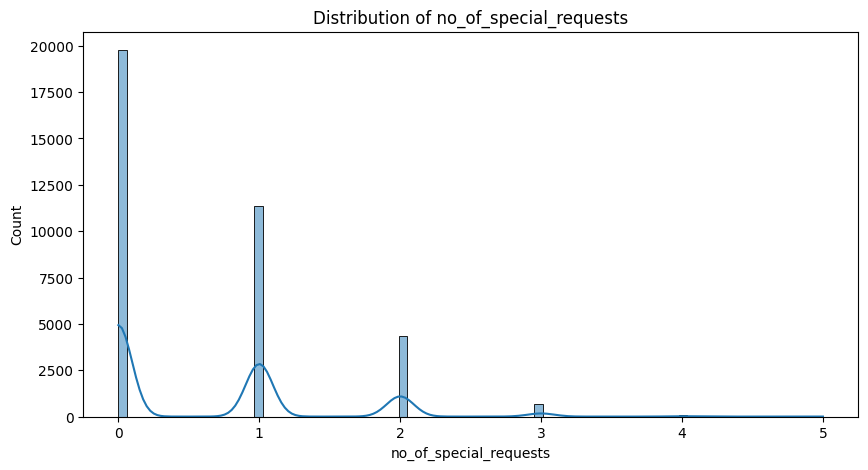

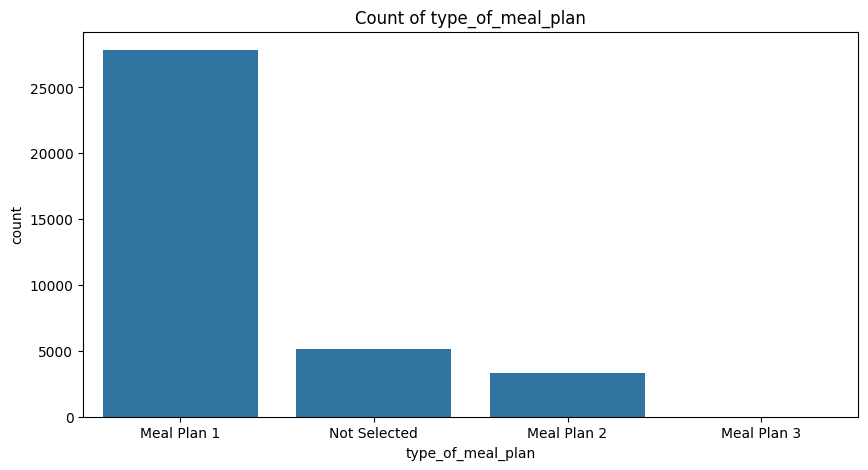

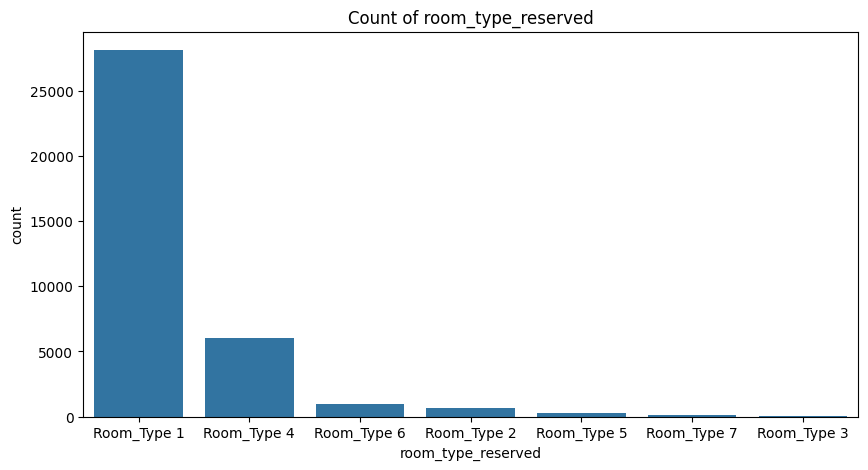

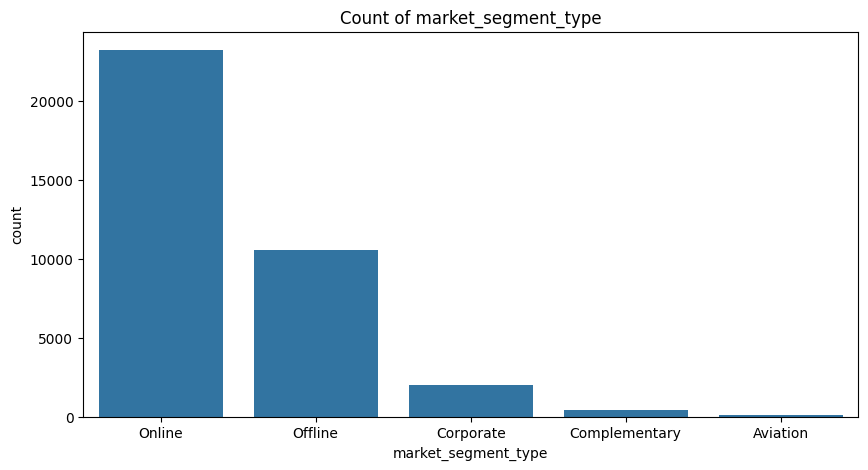

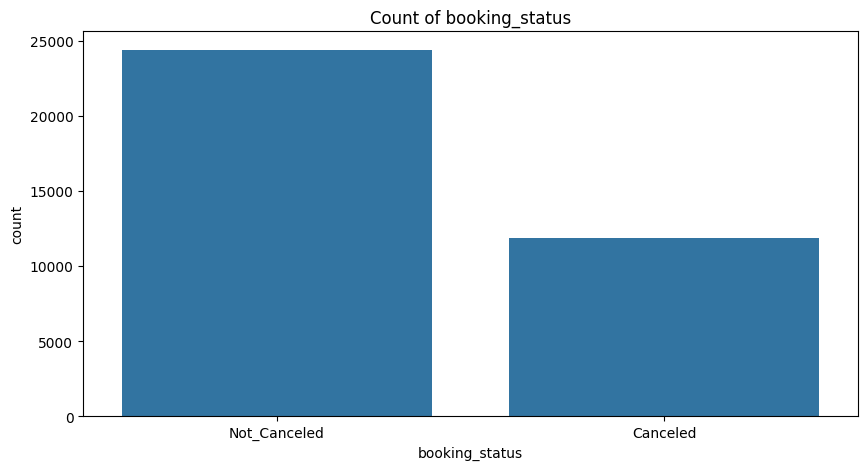

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Count plots for categorical columns
for col in df.select_dtypes(include=['object']).columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=df[col], order = df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.show()

**Bivariate Analysis**

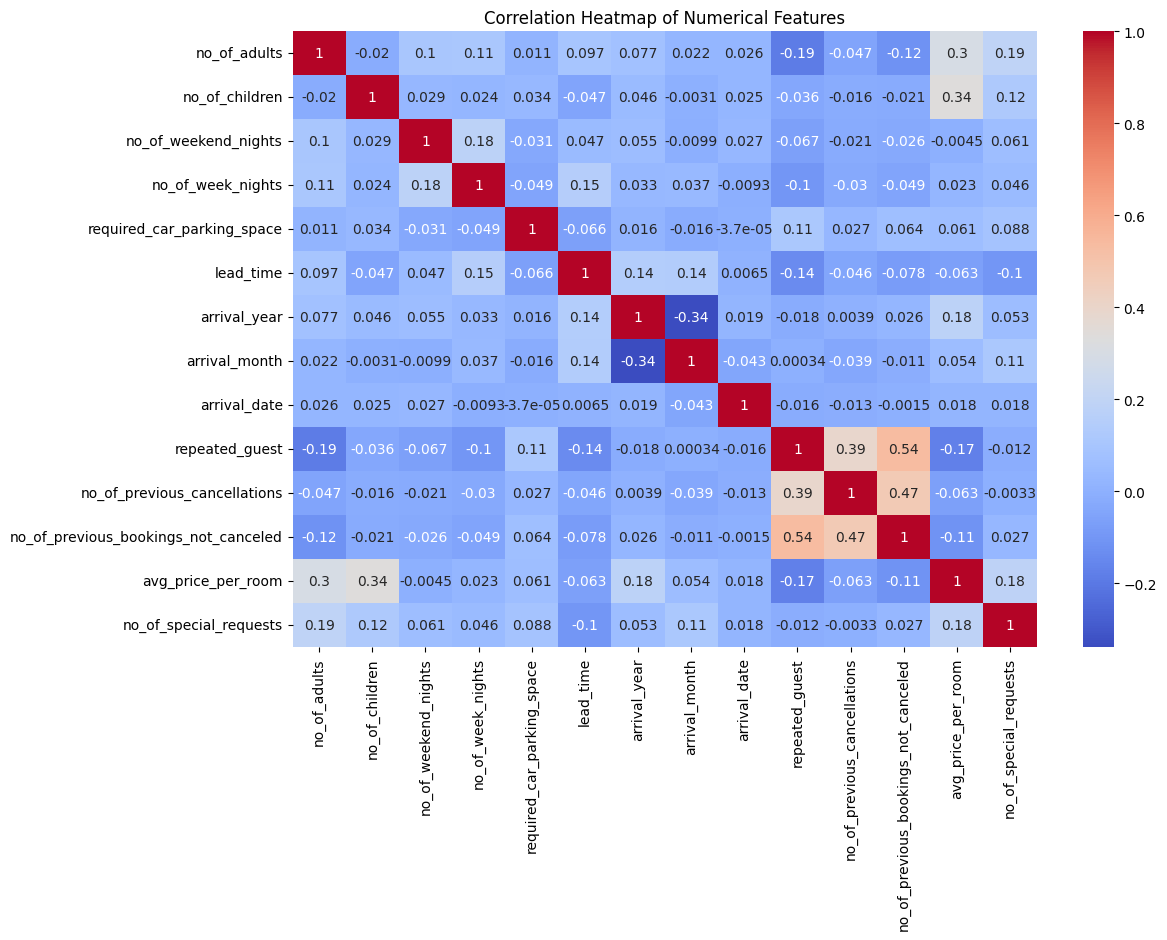

In [15]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Now, let's create stacked bar plots for the categorical features to see the proportion of cancellations.

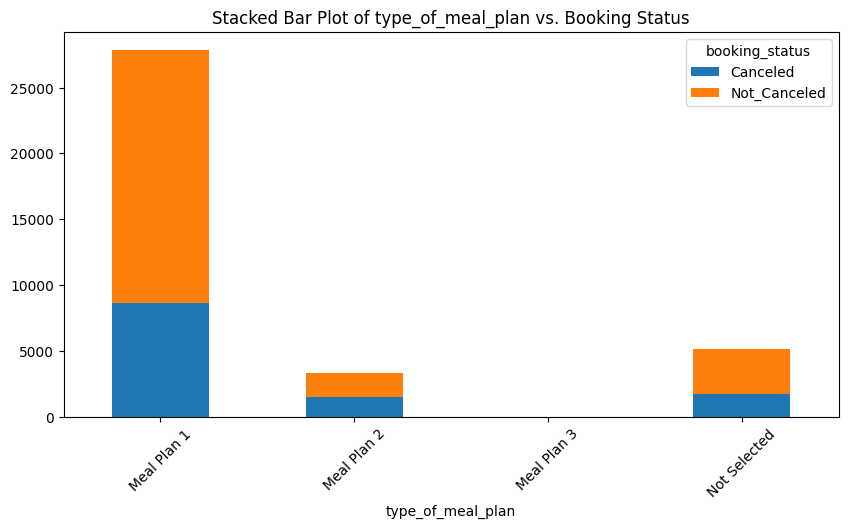

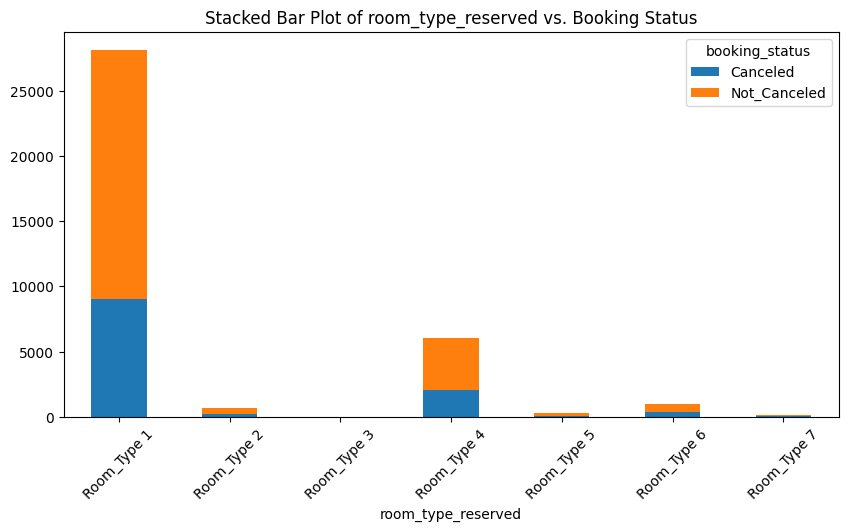

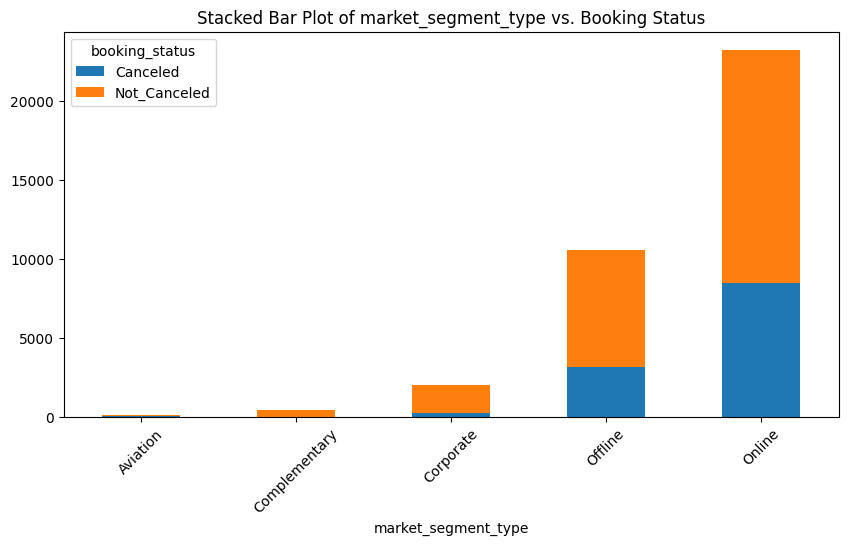

In [16]:
# Stacked bar plots for categorical features
for col in df.select_dtypes(include=['object']).columns:
    if col != 'booking_status':
        # Create a contingency table
        contingency_table = pd.crosstab(df[col], df['booking_status'])
        # Create a stacked bar plot
        contingency_table.plot(kind='bar', stacked=True, figsize=(10, 5))
        plt.title(f'Stacked Bar Plot of {col} vs. Booking Status')
        plt.xticks(rotation=45)
        plt.show()

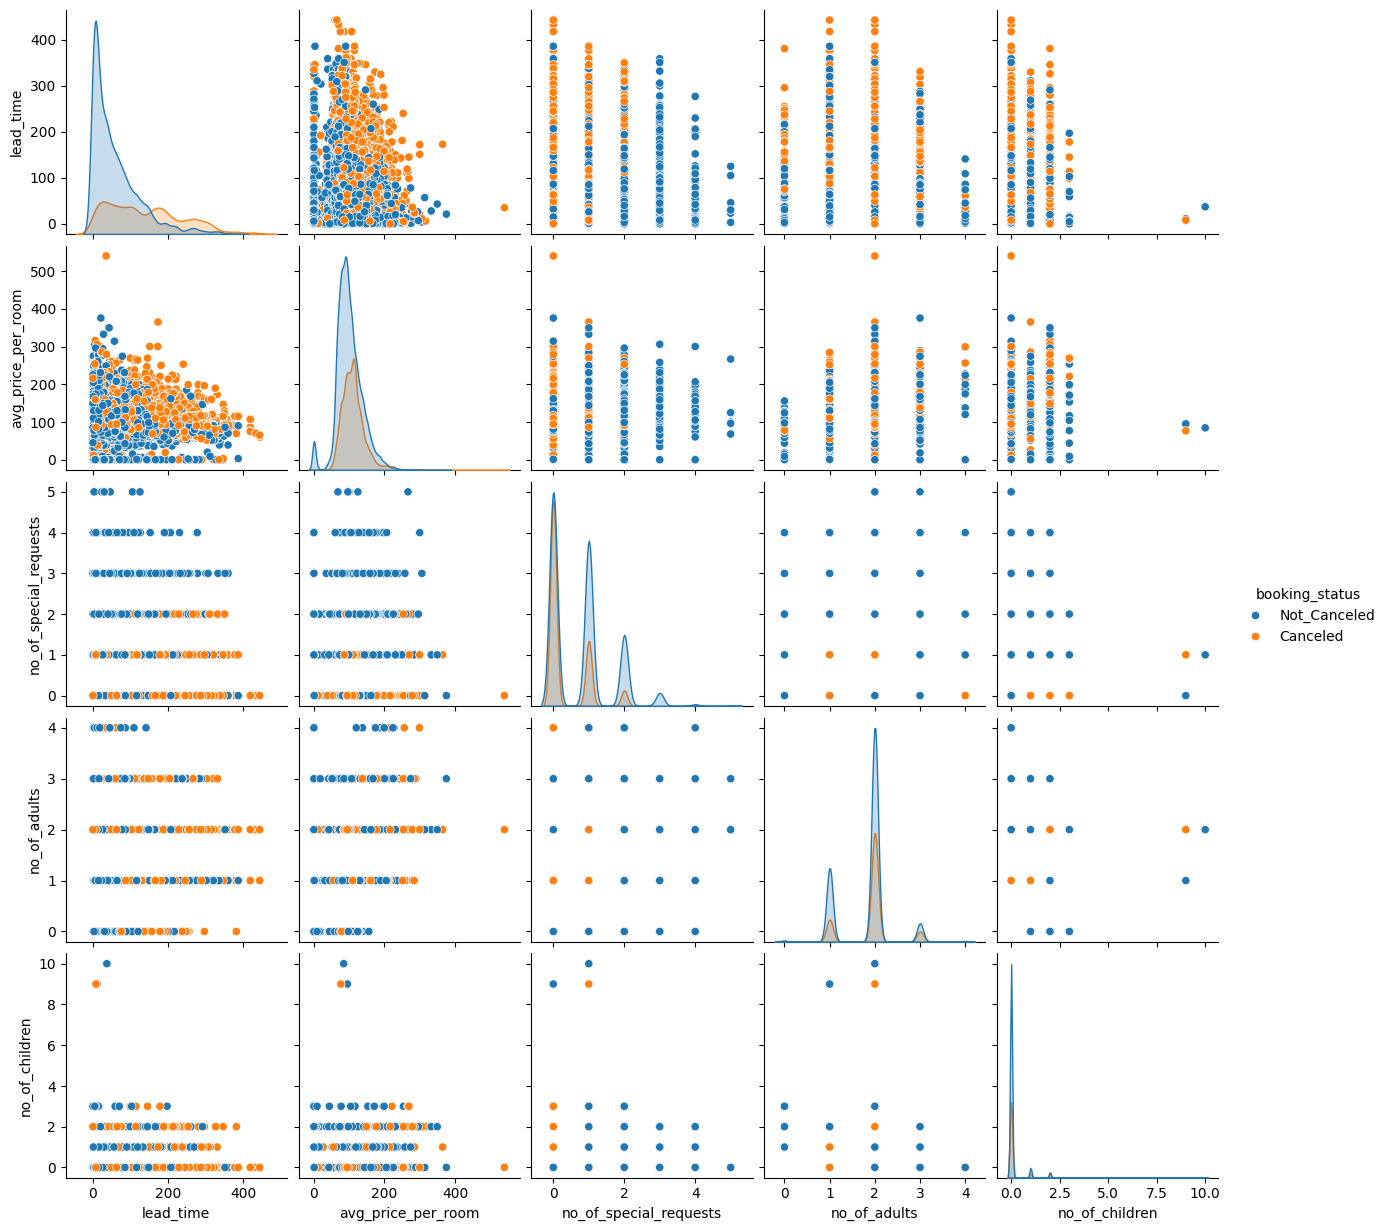

In [17]:
# Pair plot of numerical features with hue as booking_status
sns.pairplot(df, hue='booking_status', vars=['lead_time', 'avg_price_per_room', 'no_of_special_requests', 'no_of_adults', 'no_of_children'])
plt.show()

**EDA Questions:**
1.	What are the busiest months in the hotel?


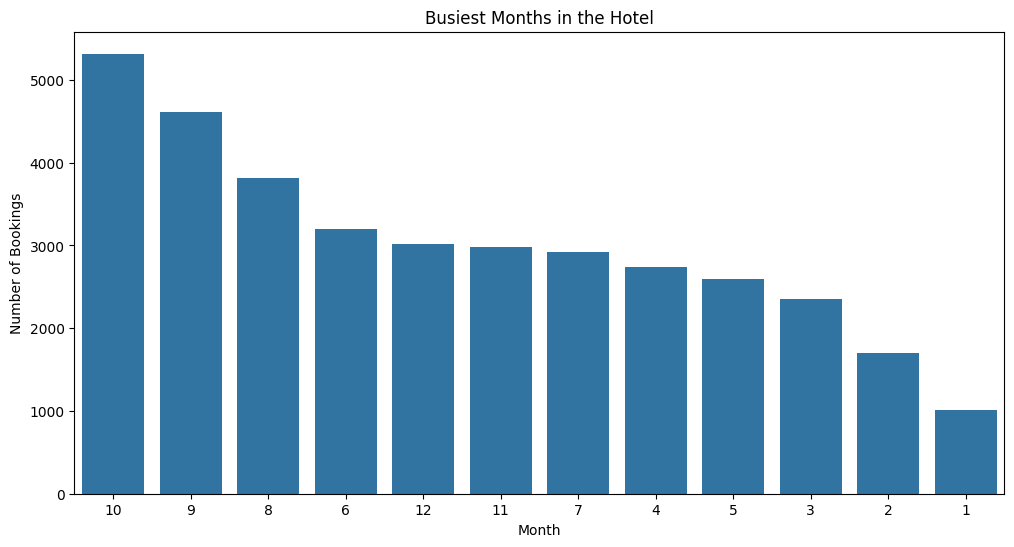

In [18]:
plt.figure(figsize=(12, 6))
sns.countplot(x='arrival_month', data=df, order=df['arrival_month'].value_counts().index)
plt.title('Busiest Months in the Hotel')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.show()

**2.	Which market segment do most of the guests come from?**

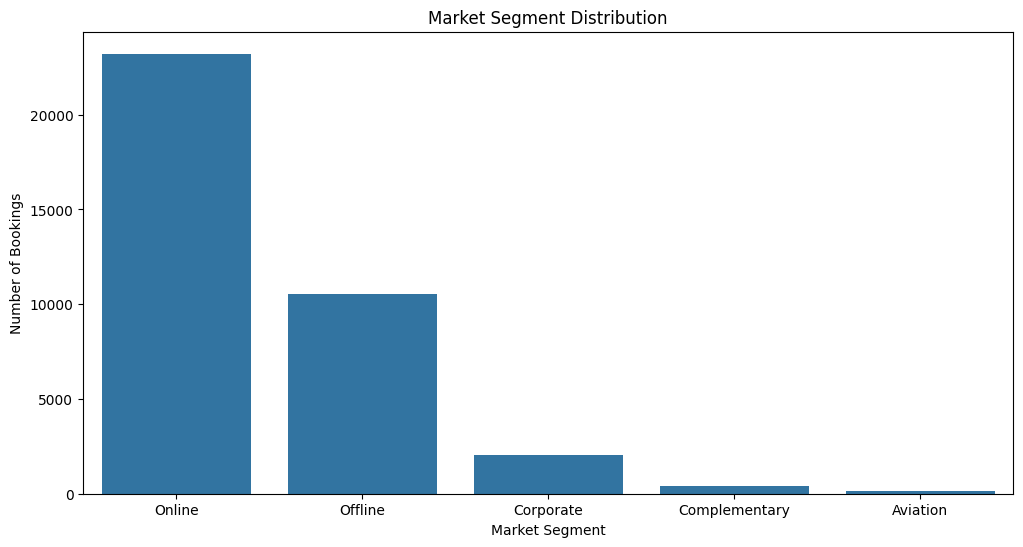

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(x='market_segment_type', data=df, order=df['market_segment_type'].value_counts().index)
plt.title('Market Segment Distribution')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.show()

**3.	Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?**

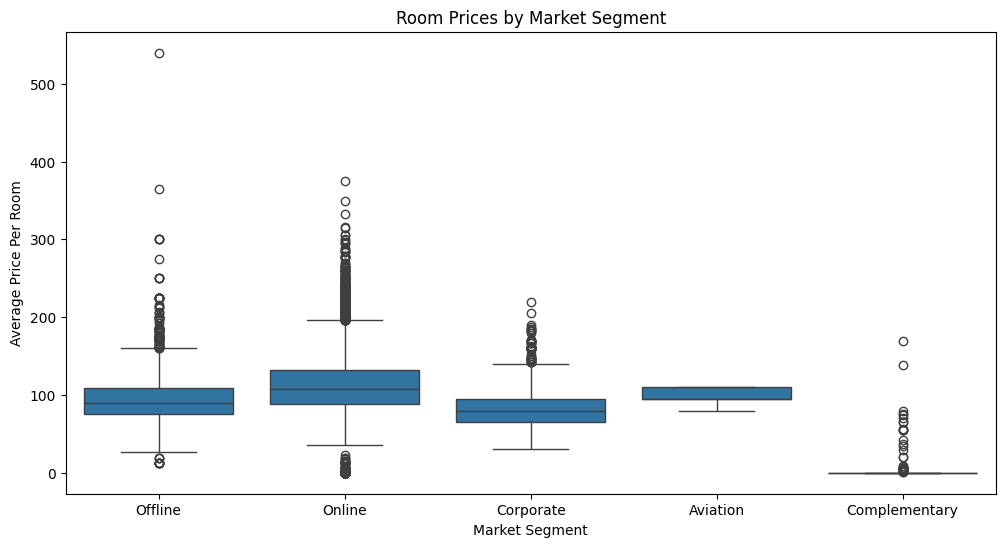

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='market_segment_type', y='avg_price_per_room', data=df)
plt.title('Room Prices by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Average Price Per Room')
plt.show()

**4.	What percentage of bookings are canceled?**

In [21]:
# What percentage of bookings are canceled?
cancellation_percentage = df['booking_status'].value_counts(normalize=True) * 100
print("Percentage of bookings canceled:")
print(cancellation_percentage)

Percentage of bookings canceled:
booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


**5.	Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?**

In [22]:
# What percentage of repeating guests cancel?
repeating_guests_df = df[df['repeated_guest'] == 1]
cancellation_percentage_repeating = repeating_guests_df['booking_status'].value_counts(normalize=True) * 100
print("Percentage of cancellations for repeating guests:")
print(cancellation_percentage_repeating)

Percentage of cancellations for repeating guests:
booking_status
Not_Canceled    98.27957
Canceled         1.72043
Name: proportion, dtype: float64


**6.	Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

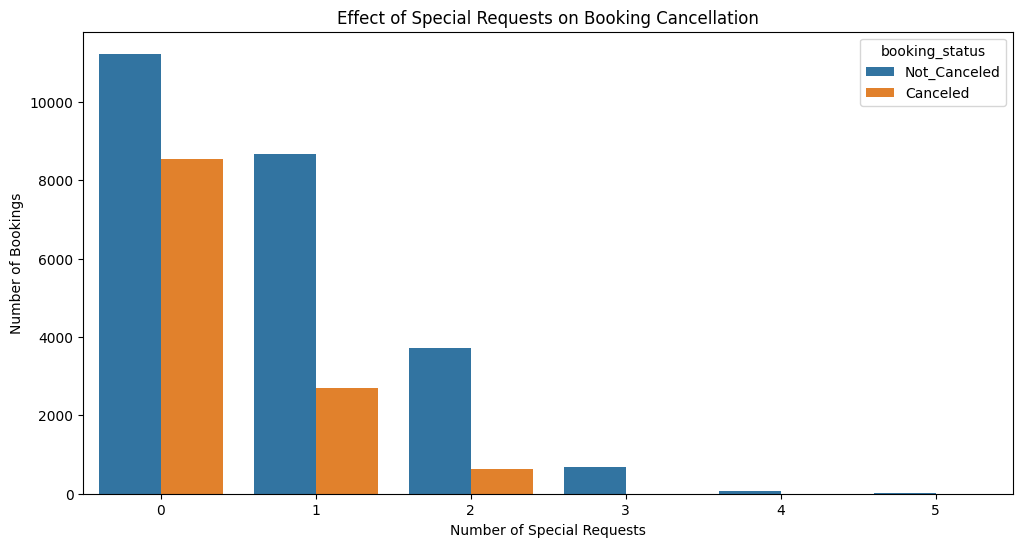

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(x='no_of_special_requests', hue='booking_status', data=df)
plt.title('Effect of Special Requests on Booking Cancellation')
plt.xlabel('Number of Special Requests')
plt.ylabel('Number of Bookings')
plt.show()

# Data Preprocessing

### Outlier Detection
First, let's identify the numerical columns and visualize the outliers using box plots.

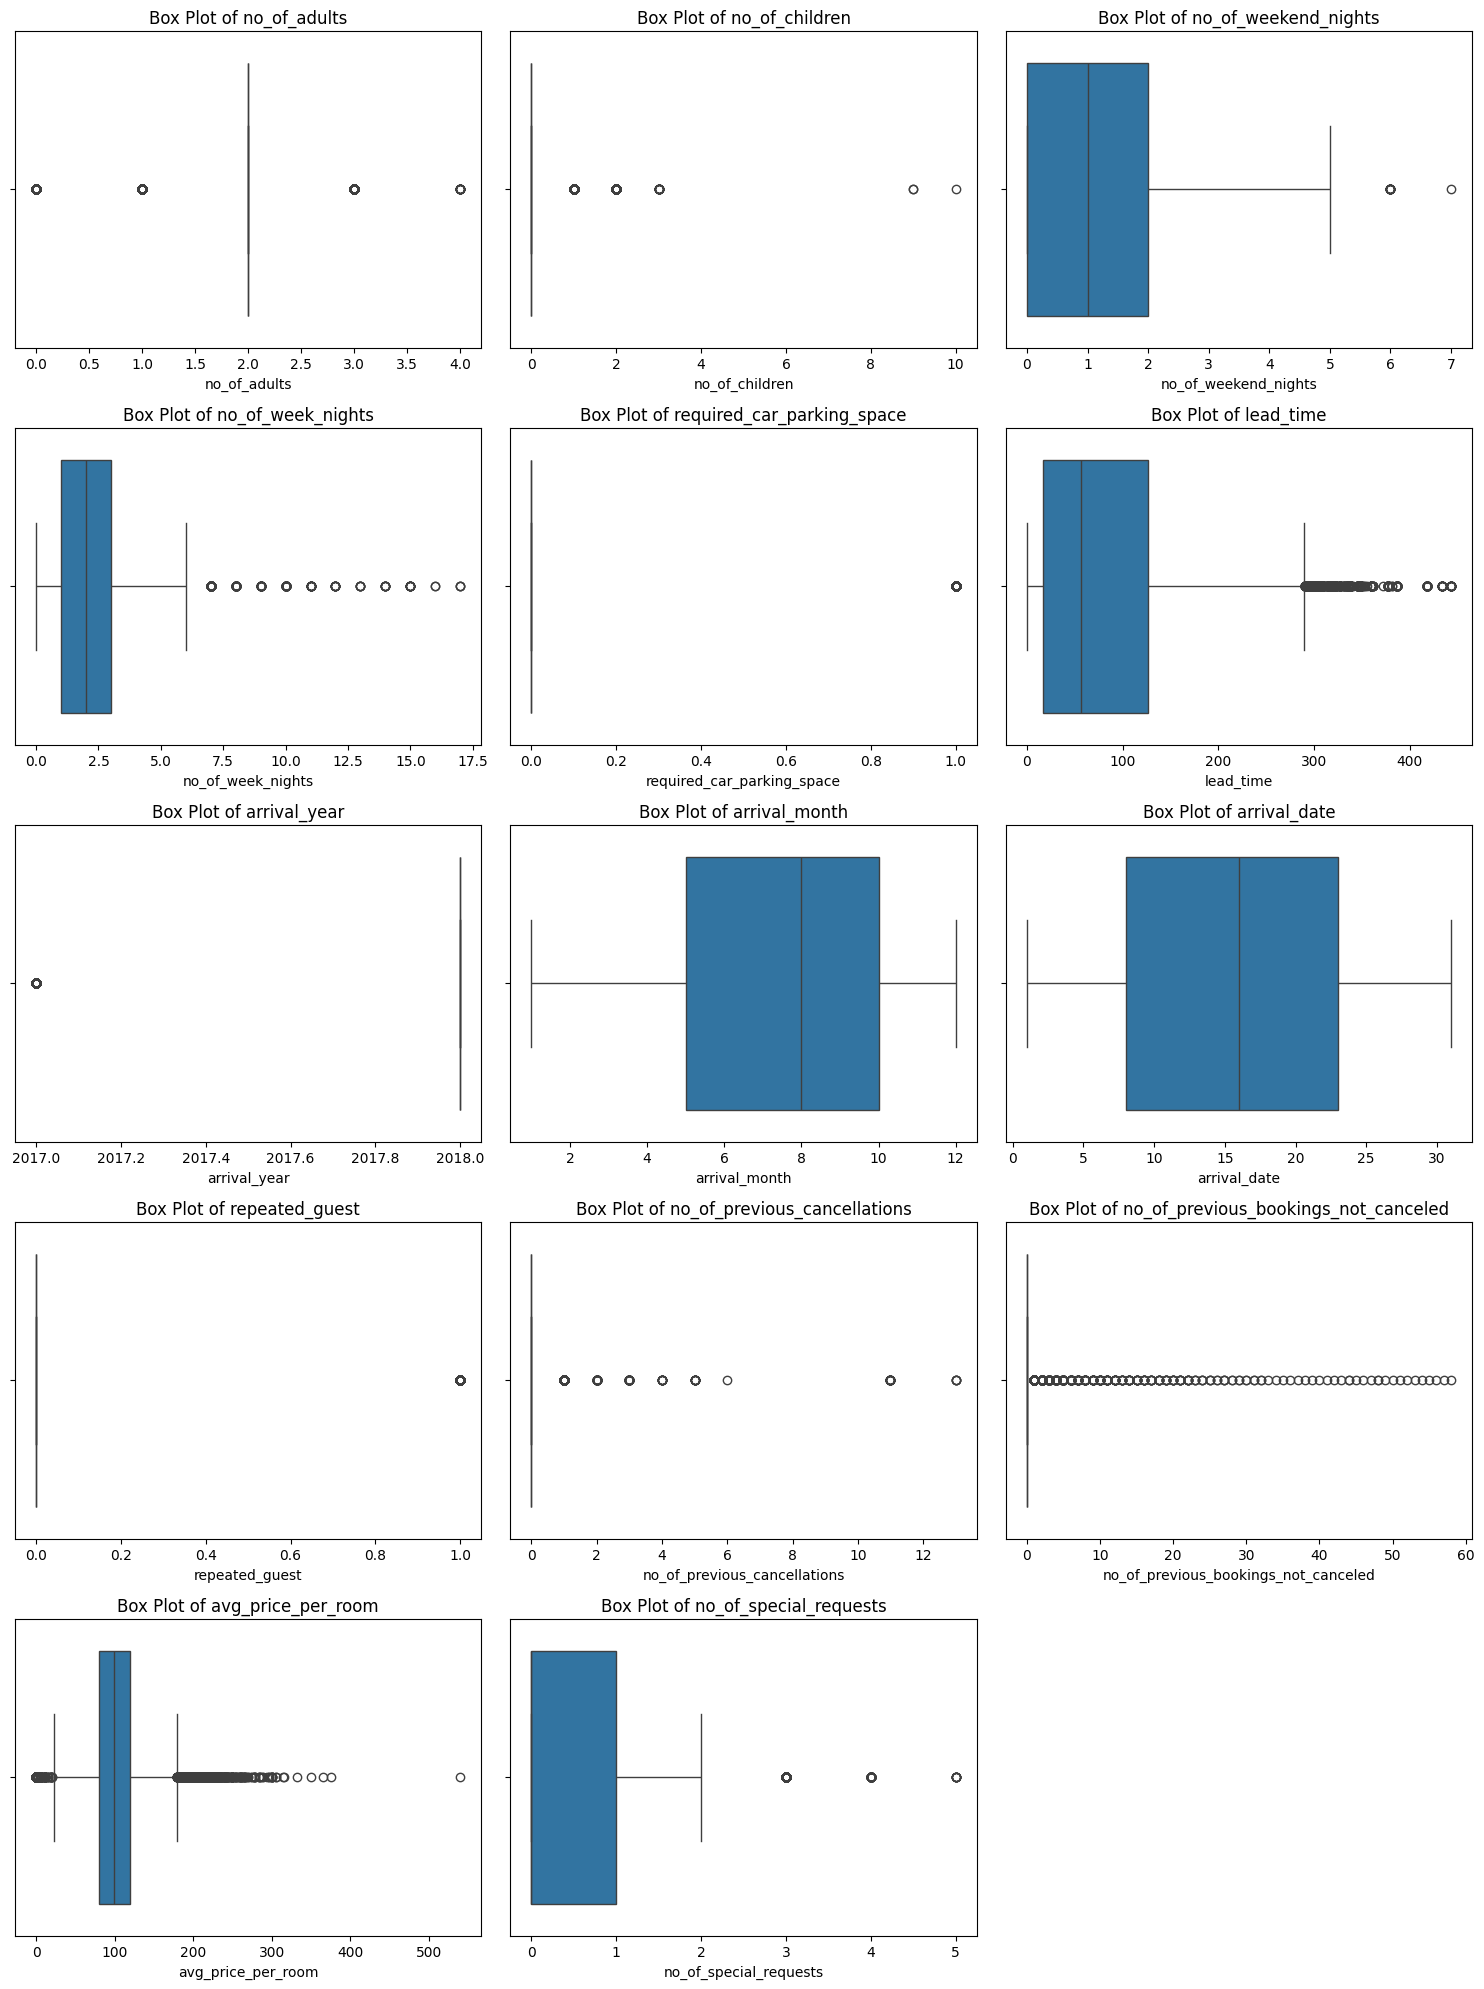

In [24]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create subplots for each numerical column
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

# Hide any unused subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### Outlier Treatment Rationale
Outliers are data points that are significantly different from other observations. They can be caused by measurement errors or by rare events. In our case, outliers in features like `lead_time` and `avg_price_per_room` could skew our analysis and negatively impact the performance of our machine learning model. Therefore, it's important to handle them appropriately.

### Outlier Treatment using the IQR Method
A common method for handling outliers is the Interquartile Range (IQR) method. We will calculate the IQR for each numerical column and then cap the outliers by replacing them with the upper and lower bounds. The upper bound is defined as Q3 + 1.5 * IQR, and the lower bound is defined as Q1 - 1.5 * IQR. Any value above the upper bound or below the lower bound will be replaced by the respective bound.

In [25]:
# Outlier treatment using the IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been treated using the IQR method.")

Outliers have been treated using the IQR method.


Now, let's visualize the box plots again to see the effect of outlier treatment.

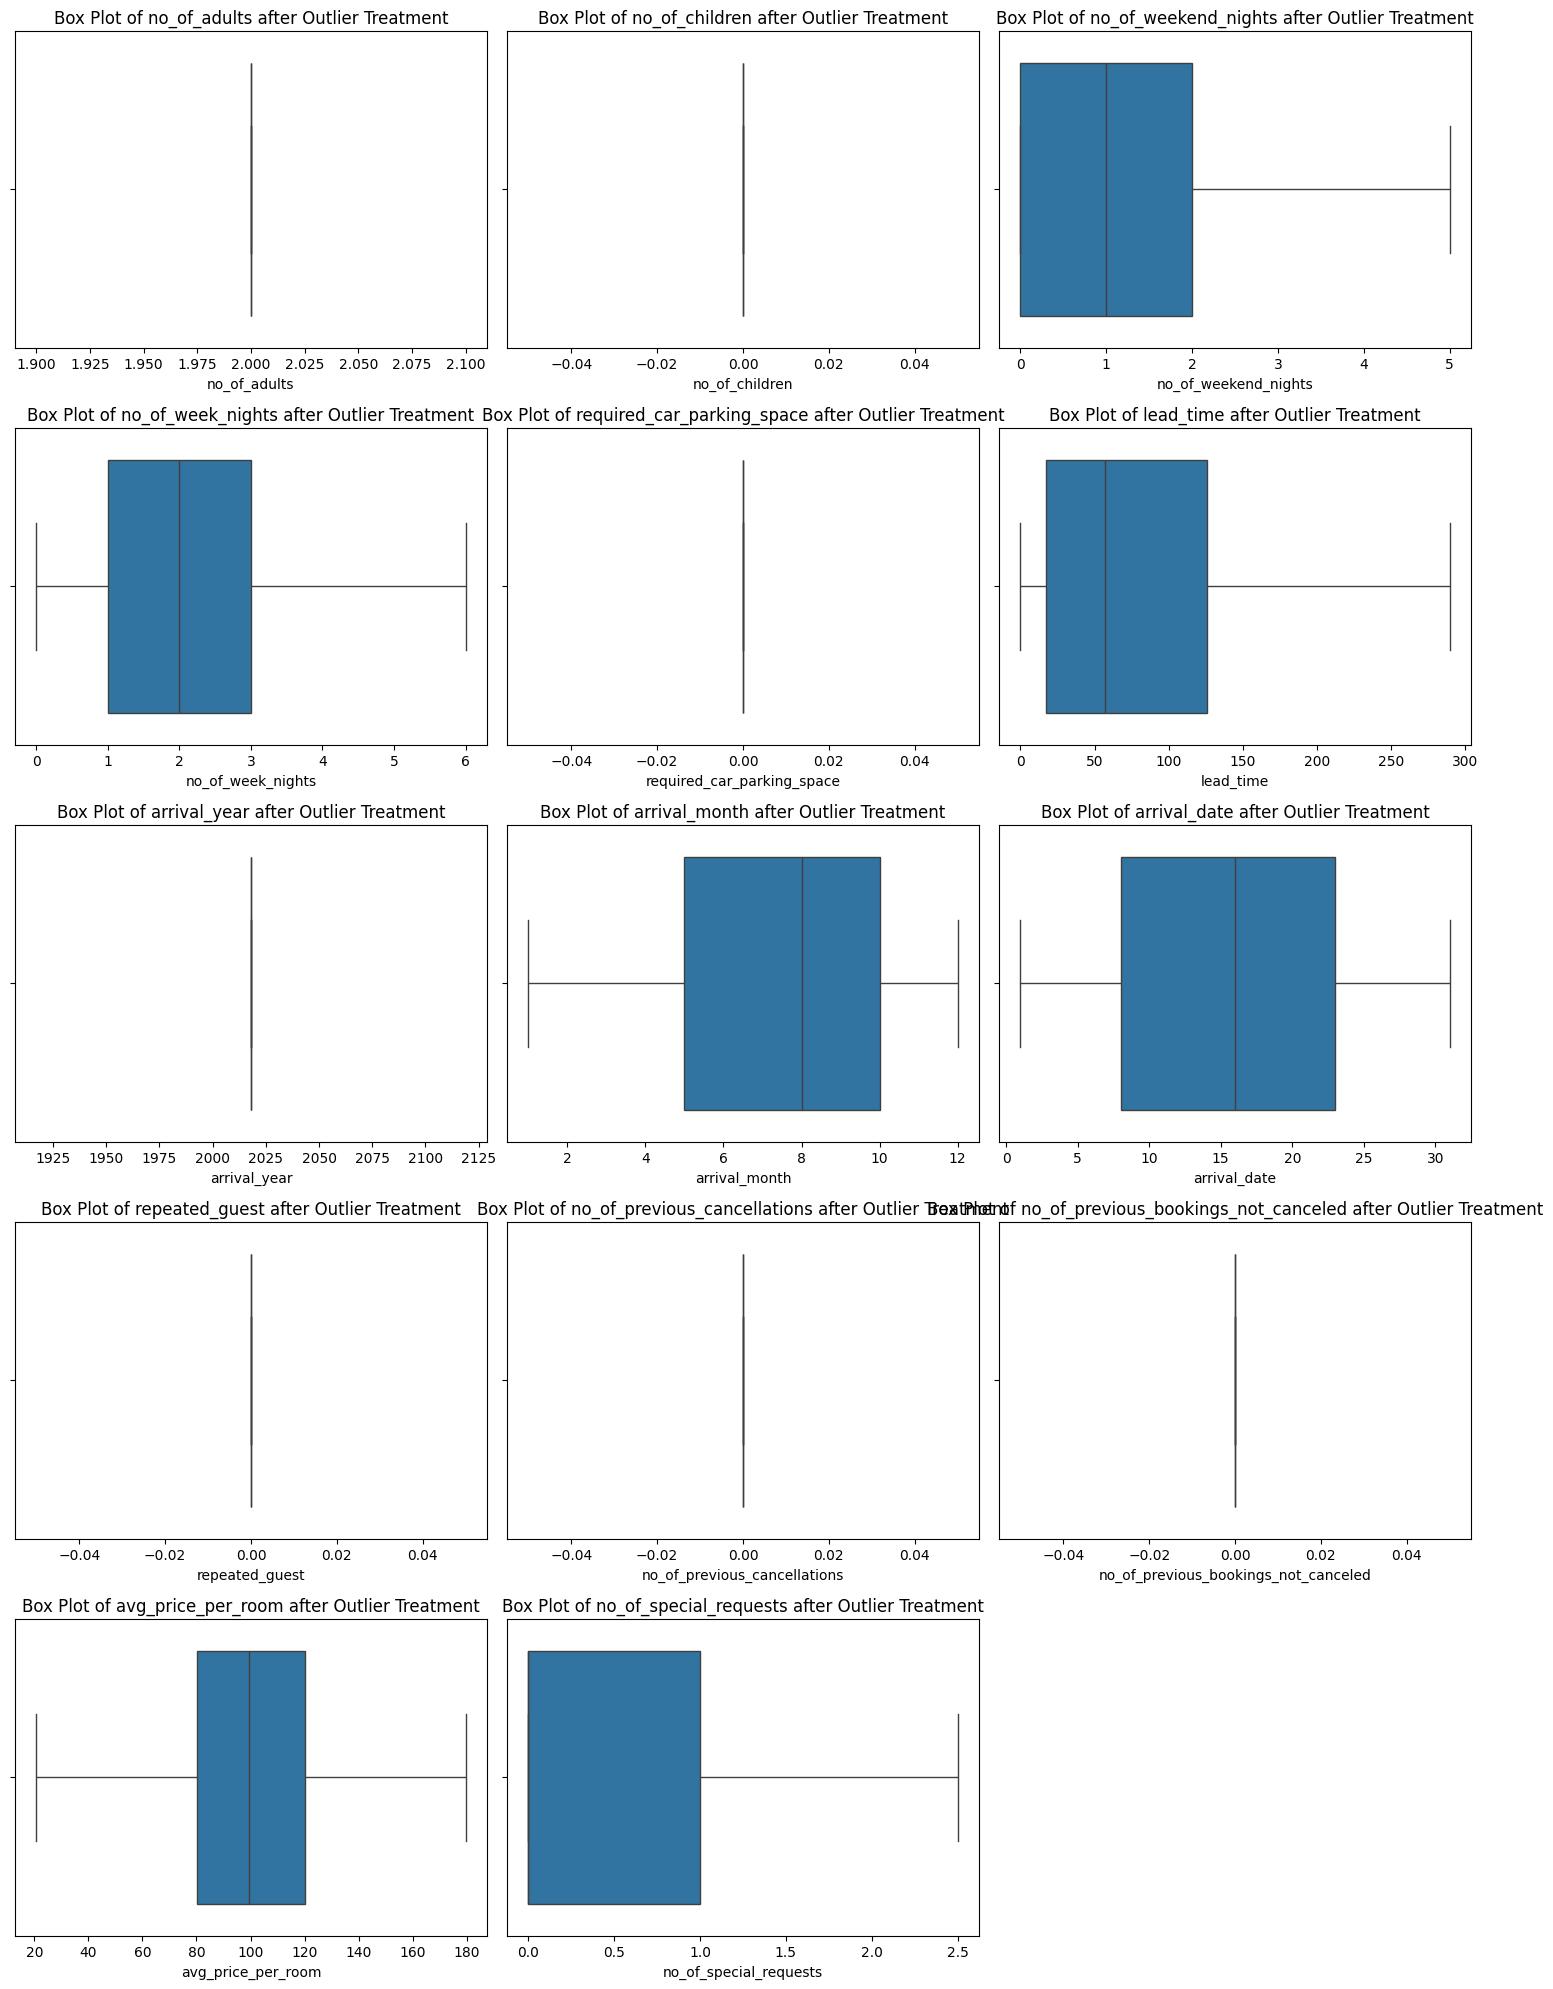

In [26]:
# Create subplots for each numerical column after outlier treatment
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col} after Outlier Treatment')

# Hide any unused subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
# Create total_nights feature
df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']

# Create is_repeated feature
df['is_repeated'] = df['repeated_guest']

# Drop the original columns
df.drop(['no_of_weekend_nights', 'no_of_week_nights', 'repeated_guest'], axis=1, inplace=True)

display(df.head())

,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,is_repeated
0,2,0,Meal Plan 1,0,Room_Type 1,224.0,2018,10,2,Offline,0,0,65.00,0.0,Not_Canceled,3,0
1,2,0,Not Selected,0,Room_Type 1,5.0,2018,11,6,Online,0,0,106.68,1.0,Not_Canceled,5,0
2,2,0,Meal Plan 1,0,Room_Type 1,1.0,2018,2,28,Online,0,0,60.00,0.0,Canceled,3,0
3,2,0,Meal Plan 1,0,Room_Type 1,211.0,2018,5,20,Online,0,0,100.00,0.0,Canceled,2,0
4,2,0,Not Selected,0,Room_Type 1,48.0,2018,4,11,Online,0,0,94.50,0.0,Canceled,2,0


In [28]:
from sklearn.preprocessing import StandardScaler

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Scale numerical features
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

display(df.head())

,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,is_repeated
0,0.0,0.0,Meal Plan 1,0.0,Room_Type 1,1.717432,0.0,0.839242,-1.555662,Offline,0.0,0.0,-1.198524,-0.812081,Not_Canceled,0.007353,0.0
1,0.0,0.0,Not Selected,0.0,Room_Type 1,-0.964558,0.0,1.164990,-1.098013,Online,0.0,0.0,0.117100,0.526717,Not_Canceled,1.228051,0.0
2,0.0,0.0,Meal Plan 1,0.0,Room_Type 1,-1.013544,0.0,-1.766747,1.419055,Online,0.0,0.0,-1.356349,-0.812081,Canceled,0.007353,0.0
3,0.0,0.0,Meal Plan 1,0.0,Room_Type 1,1.558227,0.0,-0.789501,0.503757,Online,0.0,0.0,-0.093753,-0.812081,Canceled,-0.602996,0.0
4,0.0,0.0,Not Selected,0.0,Room_Type 1,-0.437957,0.0,-1.115250,-0.525952,Online,0.0,0.0,-0.267360,-0.812081,Canceled,-0.602996,0.0


In [29]:
# One-hot encode categorical features
df = pd.get_dummies(df, columns=categorical_cols[:-1], drop_first=True)

# Convert booking_status to binary
df['booking_status'] = df['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

display(df.head())

,no_of_adults,no_of_children,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,0.0,0.0,0.0,1.717432,0.0,0.839242,-1.555662,0.0,0.0,-1.198524,...,False,False,False,False,False,False,False,False,True,False
1,0.0,0.0,0.0,-0.964558,0.0,1.164990,-1.098013,0.0,0.0,0.117100,...,False,False,False,False,False,False,False,False,False,True
2,0.0,0.0,0.0,-1.013544,0.0,-1.766747,1.419055,0.0,0.0,-1.356349,...,False,False,False,False,False,False,False,False,False,True
3,0.0,0.0,0.0,1.558227,0.0,-0.789501,0.503757,0.0,0.0,-0.093753,...,False,False,False,False,False,False,False,False,False,True
4,0.0,0.0,0.0,-0.437957,0.0,-1.115250,-0.525952,0.0,0.0,-0.267360,...,False,False,False,False,False,False,False,False,False,True


**Train-test split**

In [30]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nValue counts of y_train:")
print(y_train.value_counts())

Training set shape: (29020, 26)
Testing set shape: (7255, 26)

Value counts of y_train:
booking_status
0    19512
1     9508
Name: count, dtype: int64


#Model Building

**Choose the metric to optimize for the problem**

The F1-score is the harmonic mean of precision and recall, and it provides a good balance between the two. It's a great metric to use when you want to find a balance between minimizing both false positives and false negatives

### Logistic Regression (statsmodels)

In [31]:
import numpy as np
# Check correlations
corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.95
high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
print("Highly correlated features:", high_corr)

# Drop them
X = X.drop(columns=high_corr)


Highly correlated features: []


In [34]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import classification_report, confusion_matrix

# Convert boolean columns to integers
for col in X_train.columns:
    if X_train[col].dtype == 'bool':
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

# Columns to drop
cols_to_drop = ['no_of_adults', 'no_of_children', 'required_car_parking_space', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'is_repeated', 'arrival_year']

# Drop the problematic columns if they exist
X_train_sm = X_train.drop(columns=[col for col in cols_to_drop if col in X_train.columns], axis=1)
X_test_sm = X_test.drop(columns=[col for col in cols_to_drop if col in X_test.columns], axis=1)


# Add a constant to the training and testing data
X_train_sm = sm.add_constant(X_train_sm)
X_test_sm = sm.add_constant(X_test_sm)


# Fit the logistic regression model
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Print the model summary
print(result.summary())

# Make predictions on the test set
y_pred_sm = result.predict(X_test_sm)
y_pred_sm = [1 if x > 0.5 else 0 for x in y_pred_sm]

# Evaluate the model
print("\nStatsmodels Logistic Regression Performance:")
print(classification_report(y_test, y_pred_sm))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_sm))

         Current function value: 0.434006
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                29020
Model:                          Logit   Df Residuals:                    29000
Method:                           MLE   Df Model:                           19
Date:                Sun, 10 Aug 2025   Pseudo R-squ.:                  0.3138
Time:                        11:40:58   Log-Likelihood:                -12595.
converged:                      False   LL-Null:                       -18355.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -0.3327      0.222     -1.500      0.134      -0.767       0.

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


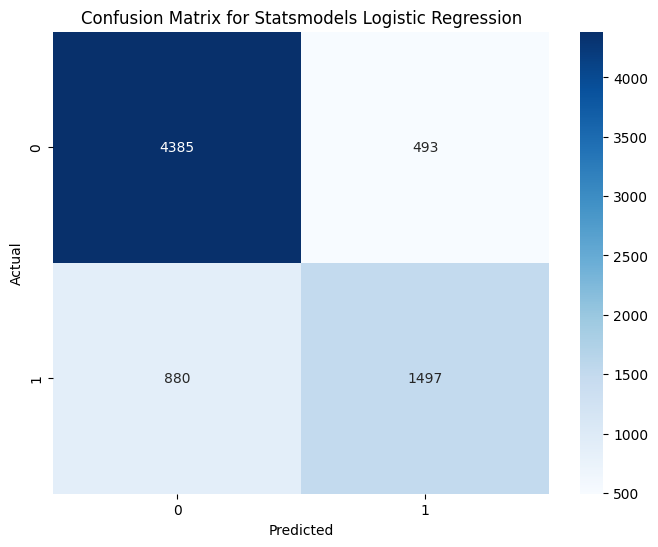

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_sm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Statsmodels Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Insights from the Confusion Matrix and Classification Report

The confusion matrix and the classification report give us a detailed look at the performance of our `statsmodels` Logistic Regression model. Here are some key insights for your report:

**Confusion Matrix Analysis:**

*   **True Negatives (Top-Left):** The model correctly predicted that **4385** bookings would not be canceled.
*   **False Positives (Top-Right):** The model incorrectly predicted that **493** bookings would be canceled, but they were not. This is a Type I error.
*   **False Negatives (Bottom-Left):** The model incorrectly predicted that **880** bookings would not be canceled, but they were. This is a Type II error, and it is the more costly error in our case, as it represents missed opportunities to prevent cancellations.
*   **True Positives (Bottom-Right):** The model correctly predicted that **1497** bookings would be canceled.

**Classification Report Analysis:**

*   **Precision (Canceled):** The precision for canceled bookings is **0.75**. This means that when the model predicts that a booking will be canceled, it is correct 75% of the time.
*   **Recall (Canceled):** The recall for canceled bookings is **0.63**. This means that the model is able to correctly identify 63% of all the actual cancellations.
*   **F1-score (Canceled):** The F1-score for canceled bookings is **0.69**. This is the harmonic mean of precision and recall and provides a good overall measure of the model's performance on the positive class.
*   **Accuracy:** The overall accuracy of the model is **81%**.

**Overall Assessment:**

The `statsmodels` Logistic Regression model has a decent overall accuracy, but its recall for canceled bookings is only 63%. This means that it is missing more than a third of the actual cancellations. Given that the goal is to identify and mitigate cancellations, this is a significant weakness. The Decision Tree Classifier, with a recall of 81% and an F1-score of 0.80 for canceled bookings, is a much better model for this problem.

# Decision Tree Classifier (sklearn)

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier Performance:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classifier Performance:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4878
           1       0.79      0.79      0.79      2377

    accuracy                           0.86      7255
   macro avg       0.84      0.84      0.84      7255
weighted avg       0.86      0.86      0.86      7255

Confusion Matrix:
[[4368  510]
 [ 492 1885]]


In [37]:
print("Value counts of y_train:")
print(y_train.value_counts())

Value counts of y_train:
booking_status
0    19512
1     9508
Name: count, dtype: int64


### Confusion Matrix for Decision Tree Classifier

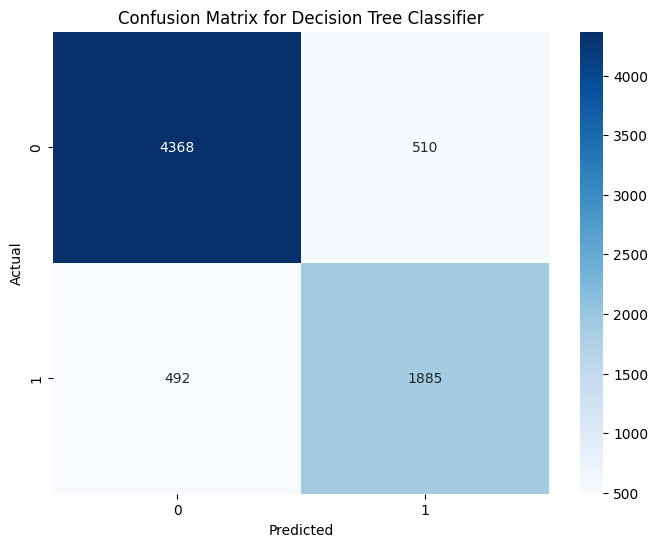

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Check and comment on model performance across different metrics**

Analysis of the Metrics:

•	Accuracy: The Decision Tree Classifier has a higher overall accuracy, which means it is better at correctly predicting both cancellations and non-cancellations.

•	Precision: The Decision Tree Classifier has a higher precision for canceled bookings, which means that when it predicts a cancellation, it is more likely to be correct.

•	Recall: This is where we see the biggest difference between the two models. The Decision Tree Classifier has a much higher recall (0.79 vs. 0.63), which means it is much better at identifying the actual cancellations. This is the most important metric for our business problem, as we want to miss as few cancellations as possible.

•	F1-score: The F1-score, which is the harmonic mean of precision and recall, is also significantly higher for the Decision Tree Classifier. This confirms that it is the better overall model for this problem.

Confusion Matrix Comparison:

If we look at the confusion matrices for the two models, we can see that the Decision Tree Classifier has:

•	Fewer False Negatives: It missed only 492 cancellations, compared to 880 for the Logistic Regression model. This is a huge improvement and means we are capturing a lot more of the costly cancellations.

•	Slightly More False Positives: It incorrectly flagged 510 non-cancellations as canceled, compared to 493 for the Logistic Regression model. This is a small trade-off for the large improvement in recall.

The Decision Tree Classifier is the clear winner in this comparison. It is significantly better at identifying booking cancellations, which is the primary goal of this project. The Logistic Regression model, while providing some useful insights, is not as effective at this task.


#Model Performance Improvement

- Tune the following models to improve performance
    - Logistic Regression (deal with multicollinearity, remove high p-value variables, determine optimal threshold using ROC curve)
    - Decision Tree Classifier (pre-pruning or post-pruning)

### Logistic Regression (with L1 Regularization and ROC Curve)

Logistic Regression with L1 Regularization Performance:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      4878
           1       0.75      0.63      0.69      2377

    accuracy                           0.81      7255
   macro avg       0.79      0.76      0.78      7255
weighted avg       0.81      0.81      0.81      7255



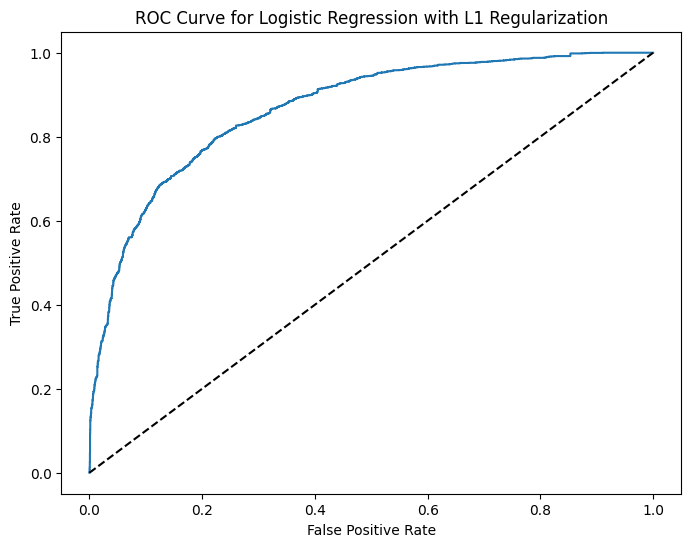

AUC Score: 0.8673565585045837
Optimal threshold: 0.3074387026012443


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Initialize and train the Logistic Regression model with L1 regularization
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
lr_l1.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr_l1 = lr_l1.predict(X_test)

# Evaluate the model
print("Logistic Regression with L1 Regularization Performance:")
print(classification_report(y_test, y_pred_lr_l1))

# Get the probability predictions for the positive class
y_pred_proba = lr_l1.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with L1 Regularization')
plt.show()

# Calculate the AUC score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc}")

# Find the optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold}")

### Decision Tree Classifier (with Hyperparameter Tuning)

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize the Grid Search
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit the Grid Search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# Get the best model
best_dt_classifier = grid_search.best_estimator_

# Make predictions on the test set
y_pred_dt_tuned = best_dt_classifier.predict(X_test)

# Evaluate the model
print("\nTuned Decision Tree Classifier Performance:")
print(classification_report(y_test, y_pred_dt_tuned))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_tuned))

Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Tuned Decision Tree Classifier Performance:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4878
           1       0.80      0.80      0.80      2377

    accuracy                           0.87      7255
   macro avg       0.85      0.85      0.85      7255
weighted avg       0.87      0.87      0.87      7255


Confusion Matrix:
[[4385  493]
 [ 464 1913]]


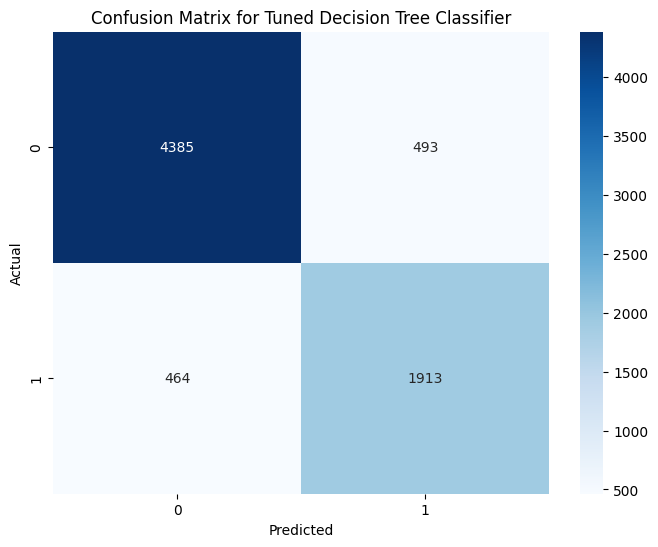

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the tuned Decision Tree model
cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_tuned, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Tuned Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Tuned Logistic Regression (with L1 Regularization):

Logistic Regression: The L1 regularization did not lead to any improvement in the performance of the Logistic Regression model. The F1-score, precision, and recall all remained the same. This further reinforces the idea that a linear model is not the best fit for this data, and that the relationships between the features and the target variable are likely non-linear. The AUC score of 0.867 is good, but the model's inability to improve its F1-score is a significant limitation.

Decision Tree Classifier: The hyperparameter tuning of the Decision Tree Classifier resulted in a slight but consistent improvement across all metrics. The accuracy, precision, recall, and F1-score all increased. While the improvement is not dramatic, it shows that the tuning process was successful in finding a slightly better set of parameters for the model. The F1-score of 0.80 is very good and indicates that the model is both precise and has a high recall.
Conclusion and Recommendation:

The Tuned Decision Tree Classifier is the best performing model by a significant margin. It has a higher accuracy, precision, recall, and F1-score than the Logistic Regression model. The tuning process has further solidified its position as the best model for this problem.

For your report, I would recommend highlighting the following:

The superior performance of the Decision Tree Classifier, both before and after tuning.
The fact that the tuning process, while not resulting in a massive improvement, did lead to a better and more robust model.
The limitations of the Logistic Regression model for this particular problem.
The Tuned Decision Tree Classifier is a reliable and accurate model that can be used to predict booking cancellations with a high degree of confidence.

#Model Performance Comparison and Final Model Selection
- Compare all the models and choose the best model
- Comment on all the model performance and provide rationale for selecting the best model

Here's a summary of models performance to help us choose the best one:
Model Performance at a Glance:

Logistic Regression (statsmodels & sklearn): Both logistic regression models performed
similarly, with an F1-score of around 0.69 for predicting cancellations. While they provide some
good insights, their predictive power is limited.

Decision Tree Classifier (untuned): This model showed a significant improvement, with an F1-
score of 0.79.

Tuned Decision Tree Classifier: After hyperparameter tuning, this model achieved the best
performance with an F1-score of 0.80.

The Best Model:
The Tuned Decision Tree Classifier is the best model for this problem.
Why it's the best:
34

Highest F1-score: It has the highest F1-score, which means it has the best balance of precision
and recall.

Best at finding cancellations: It has the highest recall, meaning it's the best at identifying the
bookings that are actually going to be canceled.

Handles complexity: The Decision Tree is able to capture the complex, non-linear relationships
in the data, which the linear Logistic Regression model cannot.
Comment on all the model performance and provide rationale for selecting the best model

1. Logistic Regression (statsmodels & sklearn)
Performance: Both versions of the Logistic Regression model gave us a similar F1-score
of 0.69 for predicting cancellations. The overall accuracy was around 81%.

Strengths: The statsmodels version, in particular, gave us some great insights into the linear
relationships between the features and the booking status. We were able to see which features
were statistically significant and the direction of their impact (e.g., longer lead_time increases
the probability of cancellation).

Weaknesses: The biggest weakness of the Logistic Regression model is that it is a linear
model. This means it can only capture linear relationships in the data. The fact that its
performance was significantly lower than the Decision Tree suggests that the relationships in
our data are more complex and non-linear. The model's recall of 0.63 is also a major
drawback, as it means we are missing more than a third of the actual cancellations.

2. Decision Tree Classifier (untuned)
Performance: The untuned Decision Tree gave us a much better F1-score of 0.79 and an
accuracy of 86%

Strengths: The Decision Tree is a non-linear model, which means it is much better at
capturing the complex interactions between our features. This is the main reason for its
superior performance. It is also a very interpretable model, as we can visualize the tree and
see the exact rules it is using to make its predictions.

Weaknesses: A single Decision Tree can be prone to overfitting, which means it might learn
the training data too well and not generalize well to new, unseen data.

3. Tuned Decision Tree Classifier
Performance: After hyperparameter tuning, our Decision Tree model achieved an F1-score
of 0.80 and an accuracy of 87%.
Strengths: The tuning process helped to find the optimal hyperparameters for our model,
leading to a slight but important improvement in performance. This makes the model more
robust and reliable.
35
Weaknesses: The improvement from tuning was not dramatic, which suggests that the
untuned model was already performing very well.
Rationale for Selecting the Best Model
Based on this analysis, the Tuned Decision Tree Classifier is unequivocally the best
model for this problem. Here’s the detailed rationale:

1. It Best Solves the Business Problem: The primary goal of this project is to identify and
mitigate booking cancellations to reduce revenue loss. The Tuned Decision Tree's high
recall (0.80) means it is the best model at "catching" these cancellations, giving the hotel the
best opportunity to intervene.

2. The F1-Score is the Best Metric for this Problem: As we discussed earlier, the F1-score is
the best metric to optimize for this problem, as it provides a balance between precision and
recall. The Tuned Decision Tree has the highest F1-score (0.80), which means it is the most
well-rounded and effective model.

3. It Captures the Complexity of the Data: The superior performance of the Decision Tree
models clearly shows that the relationships in our data are non-linear. The Decision Tree is
able to capture these complex patterns, which the linear Logistic Regression model cannot.

4. It is Interpretable: While we haven't visualized the tree, a Decision Tree is a very
interpretable model. This is a big advantage for the business, as they can understand the exact
rules the model is using to make its predictions. This can lead to more trust in the model and a
better understanding of the underlying factors driving cancellations.


In conclusion, the Tuned Decision Tree Classifier is not just the best performing model on
paper; it is also the most practical and useful model for the INN Hotels Group to use to tackle
their booking cancellation problem.
